In [1]:
import pandas as pd

In [2]:
orders = pd.read_csv('/Users/karinasouza/Desktop/Tripleten/Projects/S3_instacart_analysis/instacart_orders.csv', sep=';')
products = pd.read_csv('/Users/karinasouza/Desktop/Tripleten/Projects/S3_instacart_analysis/products.csv', sep=';')
order_products = pd.read_csv('/Users/karinasouza/Desktop/Tripleten/Projects/S3_instacart_analysis/order_products.csv.zip', sep=';')
aisles = pd.read_csv('/Users/karinasouza/Desktop/Tripleten/Projects/S3_instacart_analysis/aisles.csv', sep=';')
departments = pd.read_csv('/Users/karinasouza/Desktop/Tripleten/Projects/S3_instacart_analysis/departments.csv', sep=';')

In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [4]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [5]:
order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [6]:
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [7]:
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [8]:
# Convert to numeric, turning any non-numeric entries into NaN
orders['days_since_prior_order'] = pd.to_numeric(
    orders['days_since_prior_order'],
    errors = 'coerce'
    )

In [9]:
orders.isna().sum()

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28819
dtype: int64

In [10]:
# Count rows representing a customer’s very first order
num_first_orders = (
    (orders["order_number"] == 1) 
    &
    (orders['days_since_prior_order'].isna())
    ).sum()
num_first_orders

np.int64(28819)

In [11]:
orders.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [12]:
# Convert to numeric ints (nullable); bad entries become NaN
orders['days_since_prior_order'] = pd.to_numeric(
    orders['days_since_prior_order'],
    errors = 'coerce').astype('Int64')
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   order_id                478967 non-null  int64
 1   user_id                 478967 non-null  int64
 2   order_number            478967 non-null  int64
 3   order_dow               478967 non-null  int64
 4   order_hour_of_day       478967 non-null  int64
 5   days_since_prior_order  450148 non-null  Int64
dtypes: Int64(1), int64(5)
memory usage: 22.4 MB


In [13]:
orders.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30
1,1690866,163593,5,5,12,9
2,1454967,39980,4,5,19,2
3,1768857,82516,56,0,20,10
4,3007858,196724,2,4,12,17


In [14]:
products.isna().sum()

product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64

In [15]:
# Keep only rows where 'product_name' is missing
missing = products[products['product_name'].isna()]
missing.head()

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21


In [16]:
# Counts how many distinct aisle_id values exist excluding NaN / <NA> and returns the unique aisle_id values as an array
unique_aisles = missing['aisle_id'].dropna().unique()
print(f"Unique aisle_id count: {unique_aisles.size}")
print("Aisle IDs:", unique_aisles)

Unique aisle_id count: 1
Aisle IDs: [100]


In [17]:
orders.duplicated().sum()

np.int64(15)

In [18]:
orders[orders.duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2
223105,2160484,107525,16,3,2,30
230807,1918001,188546,14,3,2,16
266232,1782114,106752,1,3,2,<NA>
273805,1112182,202304,84,3,2,6
284038,2845099,31189,11,3,2,7
311713,1021560,53767,3,3,2,9
321100,408114,68324,4,3,2,18
323900,1919531,191501,32,3,2,7
345917,2232988,82565,1,3,2,<NA>


In [19]:
# Counts duplicated order_id rows (15) and then lists every duplicate record, grouped by order_id
orders.duplicated(subset=['order_id']).sum()
orders[orders.duplicated(subset=['order_id'], keep=False)].sort_values('order_id')

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
354993,391768,57671,19,3,2,10
371905,391768,57671,19,3,2,10
119251,408114,68324,4,3,2,18
321100,408114,68324,4,3,2,18
394347,467134,63189,21,3,2,2
250626,467134,63189,21,3,2,2
99462,794638,50898,24,3,2,2
145574,794638,50898,24,3,2,2
311713,1021560,53767,3,3,2,9
242618,1021560,53767,3,3,2,9


In [20]:
orders.duplicated().sum()

np.int64(15)

In [21]:
products.duplicated().sum()

np.int64(0)

In [22]:
order_products.duplicated().sum()

np.int64(0)

In [23]:
aisles.duplicated().sum()

np.int64(0)

In [24]:
departments.duplicated().sum()

np.int64(0)

#### Orders Dataframe

In [25]:
orders.duplicated().sum()

np.int64(15)

In [26]:
orders[orders.duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2
223105,2160484,107525,16,3,2,30
230807,1918001,188546,14,3,2,16
266232,1782114,106752,1,3,2,<NA>
273805,1112182,202304,84,3,2,6
284038,2845099,31189,11,3,2,7
311713,1021560,53767,3,3,2,9
321100,408114,68324,4,3,2,18
323900,1919531,191501,32,3,2,7
345917,2232988,82565,1,3,2,<NA>


In [27]:
orders = orders.drop_duplicates().reset_index(drop=True)


In [28]:
orders.duplicated().sum()

np.int64(0)

In [29]:
orders["order_id"].duplicated().sum()

np.int64(0)

#### Products Dataframe

In [30]:
products.isna().sum()

product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64

In [31]:
products["product_id"].duplicated().sum()

np.int64(0)

In [32]:
products['product_name'].str.lower().duplicated().sum()

np.int64(1361)

In [33]:
products_unknown = products[products['product_name'] == 'Unknown']
products_unknown


,product_id,product_name,aisle_id,department_id


In [34]:
products['product_name'].str.lower().str.strip().dropna().duplicated().sum()



np.int64(104)

#### Departments Dataframe

In [35]:
departments.duplicated().sum()

np.int64(0)

In [36]:
departments["department_id"].duplicated().sum()

np.int64(0)

#### Aisles Dataframe

In [37]:
aisles.duplicated().sum()

np.int64(0)

In [38]:
aisles["aisle_id"].duplicated().sum()


np.int64(0)

#### Order_Products Dataframe

In [39]:
order_products.duplicated().sum()

np.int64(0)

In [40]:
order_products.duplicated(subset=["order_id", "product_id"]).sum()

np.int64(0)

#### Products Dataframe

In [41]:
products['product_name'].isna().sum()

np.int64(1258)

In [42]:
# checking if .all missing values are in the same aisle
name_missing = products['product_name'].isna()

if name_missing.any():
    all_in_aisle_100 = (products.loc[name_missing, 'aisle_id'] == 100).all()
    print("Todos os product_name ausentes estão no aisle_id 100?", all_in_aisle_100)
else:
    print("Não há product_name ausentes para verificar.")

Todos os product_name ausentes estão no aisle_id 100? True


In [43]:
# checking if .all department is == 21
(products.loc[name_missing, 'department_id'] == 21).all()

np.True_

In [44]:
aisles.loc[aisles['aisle_id'] == 100]
departments.loc[departments['department_id'] == 21]



,department_id,department
20,21,missing


In [45]:
departments.tail(30)

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [46]:
products['product_name'] = products['product_name'].fillna('Unknown')

In [47]:
(products['product_name'] == 'Unknown').sum()

np.int64(1258)

#### Order Dataframe

In [48]:
orders.isna().sum()

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [49]:
# Checking if there are missing values for orders that are not the first order
missing_not_first = orders.loc[orders["order_number"] > 1, "days_since_prior_order"].isna().sum()
missing_not_first

np.int64(0)

#### DataFrame order_products

In [50]:
order_products.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [51]:
order_products.loc[order_products['add_to_cart_order'].isna()].head()

,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,NaN,0
9926,1968313,43867,NaN,0
14394,2926893,11688,NaN,0
16418,1717990,4142,NaN,0
30114,1959075,42828,NaN,1


In [52]:
# Get the global min (always 1) and max position an item held in any cart
order_products['add_to_cart_order'].min(), order_products['add_to_cart_order'].max()


(1.0, 64.0)

In [53]:
# Get a sorted list of order_ids that contain at least one missing add_to_cart_order value
id_orders_with_nan_value = sorted(order_products.loc[order_products['add_to_cart_order'].isna()]['order_id'].unique())
print(id_orders_with_nan_value)

[np.int64(9310), np.int64(61355), np.int64(102236), np.int64(129627), np.int64(165801), np.int64(171934), np.int64(180546), np.int64(264710), np.int64(293169), np.int64(388234), np.int64(404157), np.int64(678116), np.int64(733526), np.int64(747668), np.int64(813364), np.int64(844733), np.int64(854647), np.int64(871281), np.int64(888470), np.int64(903110), np.int64(936852), np.int64(1021563), np.int64(1038146), np.int64(1169835), np.int64(1183255), np.int64(1220886), np.int64(1302315), np.int64(1308785), np.int64(1386261), np.int64(1477139), np.int64(1529171), np.int64(1564093), np.int64(1598369), np.int64(1625713), np.int64(1633337), np.int64(1648217), np.int64(1673227), np.int64(1677118), np.int64(1713430), np.int64(1717990), np.int64(1730767), np.int64(1800005), np.int64(1832957), np.int64(1888628), np.int64(1916118), np.int64(1959075), np.int64(1961723), np.int64(1968313), np.int64(2094761), np.int64(2136777), np.int64(2170451), np.int64(2256933), np.int64(2409109), np.int64(2449164

In [54]:
# item per order
order_products[order_products['add_to_cart_order'].isna()].groupby('order_id')['product_id'].count().sort_values(ascending=False)

order_id
61355      63
3308010    51
2136777    44
171934     40
1959075    34
           ..
888470      1
1598369     1
747668      1
1677118     1
9310        1
Name: product_id, Length: 70, dtype: int64

In [55]:
# All orders with missing values contain more than 64 products?
counts = (
    order_products[order_products['order_id'].isin(id_orders_with_nan_value)]
          .groupby('order_id')['product_id'].count())
print("# All orders with missing values contain more than 64 products?", counts.min() > 64)

# Group the orders with missing values by order ID
grupos = order_products[
    order_products['add_to_cart_order'].isna()
    ].groupby('order_id')
contagens = grupos['product_id'].count()
n_pedidos = len(contagens)
print(f"Is there {n_pedidos} orders with at least one missing value in 'add_to_cart_order'?")


# Count the number of 'product_id' in each order and check the minimum count
counts = order_products[order_products['add_to_cart_order'].isna()].groupby('order_id')['product_id'].count()
print("Minimum count of product_id per order (with missing data):", counts.min())





# All orders with missing values contain more than 64 products? True
Is there 70 orders with at least one missing value in 'add_to_cart_order'?
Minimum count of product_id per order (with missing data): 1


In [56]:

# Replace missing values in 'add_to_cart_order' with 999 and convert the column to integer
order_products['add_to_cart_order'] = (
    order_products['add_to_cart_order'].fillna(999).astype('int64')
)

print(order_products['add_to_cart_order'].dtype, order_products['add_to_cart_order'].isna().sum())



int64 0


#### Data Analysis

In [57]:
print(sorted(orders['order_hour_of_day'].unique().tolist()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [58]:

print(sorted(orders['order_dow'].unique().tolist()))



[0, 1, 2, 3, 4, 5, 6]


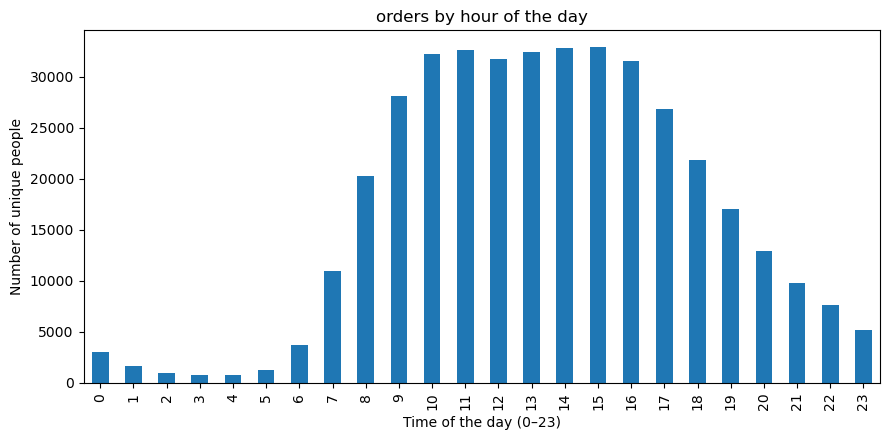

In [59]:
# How many unique users ordered in each hour of the day?
import matplotlib.pyplot as plt

people_per_hour = (orders.groupby('order_hour_of_day')['user_id']
                    .nunique()
                    .reindex(range(24), fill_value=0) 
                    .sort_index())

people_per_hour.plot(kind='bar', figsize=(9, 4.5))
plt.title('orders by hour of the day')
plt.xlabel('Time of the day (0–23)')
plt.ylabel('Number of unique people')
plt.tight_layout()
plt.show()

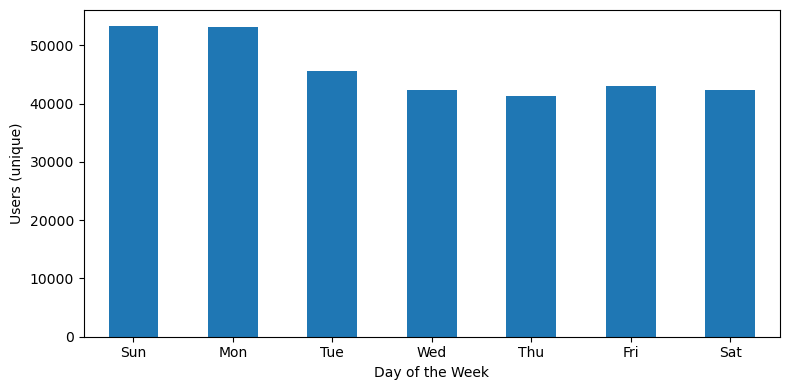

In [60]:
# Which day of the week do people buy food?
# Categorize departments into food vs non-food:

non_food = {'household','personal care','pets','babies','other','missing'}
prod_dept = products.merge(departments, on='department_id', how='left')
# all the columns from departments DF will be merged to products DF using department_id as a connector of tables. if department_id has no match it will shown as Nan.
prod_dept['is_food'] = ~prod_dept['department'].str.lower().isin(non_food)

orders_with_food = (order_products
                    .merge(prod_dept[['product_id','is_food']], on='product_id', how='left')
                    .groupby('order_id')['is_food'].any() # “this order has at least one food item”.
                    .rename('has_food')
                    .reset_index())

orders_food = orders.merge(orders_with_food, on='order_id', how='left').query('has_food == True')

people_per_dow = (orders_food.groupby('order_dow')['user_id']
                   .nunique()
                   .reindex(range(7), fill_value=0)
                   .sort_index())

dow_labels = {0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'}

labels = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']  # 0..6
ax = people_per_dow.reindex(range(7), fill_value=0).plot(kind='bar', figsize=(8,4))
ax.set_xticklabels(labels, rotation=0)
ax.set_xlabel('Day of the Week')
ax.set_ylabel('Users (unique)')
plt.tight_layout()
plt.show()


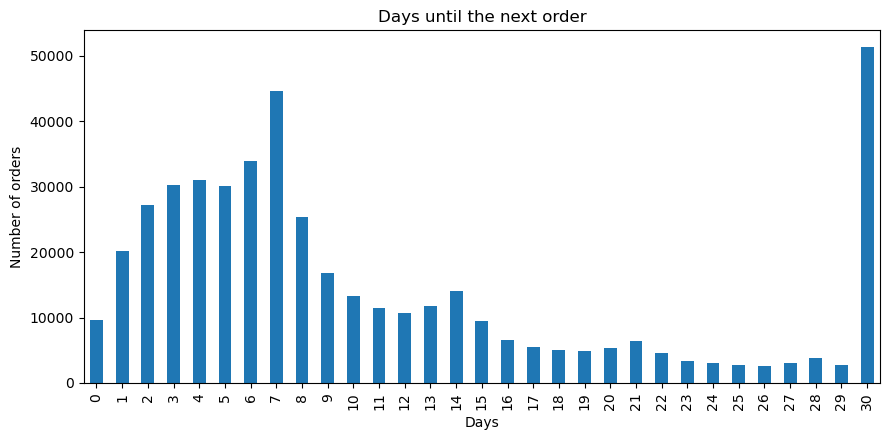

{'media_dias': 11.101813900274362, 'mediana_dias': 7.0, 'moda_dias': 30}


In [61]:
# Distribution of days until the next order
espera = pd.to_numeric(orders['days_since_prior_order'], errors='coerce').dropna().astype(int)
contagem = espera.value_counts().sort_index()

contagem.plot(kind='bar', figsize=(9, 4.5))
plt.title('Days until the next order')
plt.xlabel('Days')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

print({
    'media_dias': float(espera.mean()),
    'mediana_dias': float(espera.median()),
    'moda_dias': int(contagem.idxmax())
})

In [62]:
wednesday = (orders.loc[orders['order_dow'] == 3]
          .groupby('order_hour_of_day')['user_id'].nunique()
          .reindex(range(24), fill_value=0))
print("Wednesday (Distinct Users by Hour):\n", wednesday)


Wednesday (Distinct Users by Hour):
 order_hour_of_day
0      372
1      214
2      106
3      100
4      107
5      168
6      619
7     1644
8     2989
9     4242
10    4759
11    4804
12    4531
13    4517
14    4610
15    4954
16    4783
17    4032
18    3328
19    2586
20    1853
21    1421
22    1120
23     704
Name: user_id, dtype: int64


In [63]:
saturday = (orders.loc[orders['order_dow'] == 5]
          .groupby('order_hour_of_day')['user_id'].nunique()
          .reindex(range(24), fill_value=0))
print("Saturday (Distinct Users by Hour):\n", saturday)


Saturday (Distinct Users by Hour):
 order_hour_of_day
0      451
1      217
2      121
3       99
4      116
5      222
6      629
7     1863
8     3199
9     4480
10    5022
11    5045
12    4650
13    4882
14    5014
15    5096
16    4759
17    3994
18    3313
19    2512
20    1838
21    1324
22     995
23     760
Name: user_id, dtype: int64


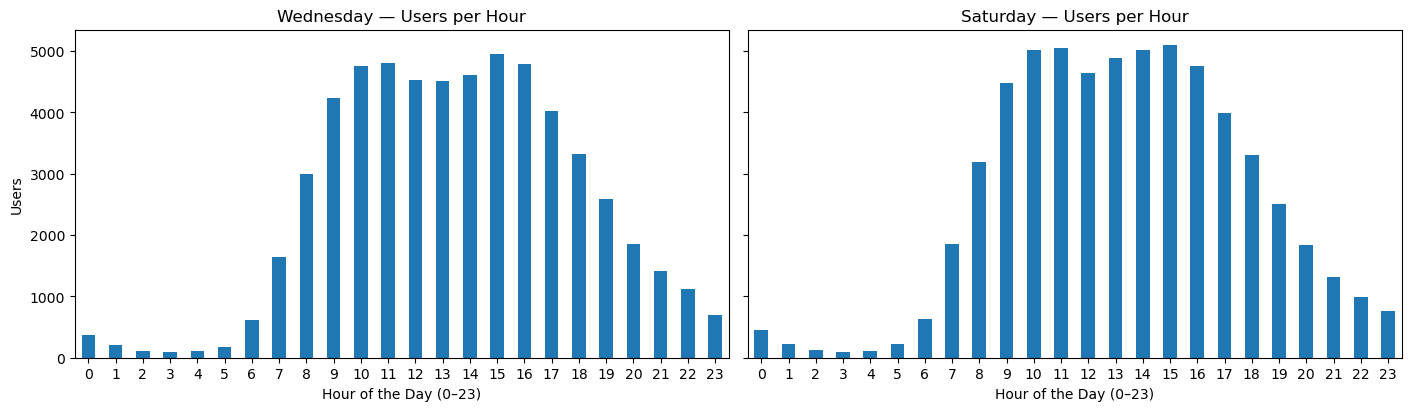

In [64]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True, constrained_layout=True)

ax = wednesday.plot(kind='bar', ax=ax1)
ax.set_title('Wednesday — Users per Hour')
ax.set_xlabel('Hour of the Day (0–23)')
ax.set_ylabel('Users')

ax = saturday.plot(kind='bar', ax=ax2)
ax.set_title('Saturday — Users per Hour')
ax.set_xlabel('Hour of the Day (0–23)')
ax.set_ylabel('Users')

for ax in (ax1, ax2):
    ax.tick_params(axis='x', labelrotation=0)

plt.show()



In [65]:
import pandas as pd

orders_per_customer = orders.groupby('user_id').size()
distribuicao = orders_per_customer.value_counts().sort_index()

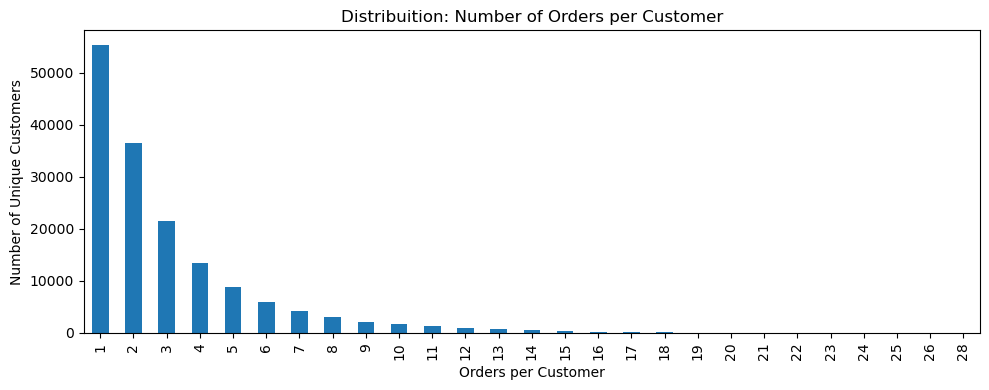

In [66]:
import matplotlib.pyplot as plt
distribuicao.plot(kind='bar', figsize=(10, 4))
plt.title('Distribuition: Number of Orders per Customer')
plt.xlabel('Orders per Customer')
plt.ylabel('Number of Unique Customers')
plt.tight_layout()
plt.show()


In [67]:
counts = (order_products
          .groupby('product_id')
          .size()
          .rename('times_bought')
          .reset_index())

print(counts)


       product_id  times_bought
0               1           280
1               2            11
2               3            42
3               4            49
4               7             2
...           ...           ...
45568       49690             5
45569       49691            72
45570       49692            12
45571       49693            25
45572       49694             9

[45573 rows x 2 columns]


In [68]:
top20 = (counts
         .sort_values('times_bought', ascending=False)
         .head(20)
         .merge(products[['product_id', 'product_name']], on='product_id', how='left'))
print(top20)


    product_id  times_bought              product_name
0        24852         66050                    Banana
1        13176         53297    Bag of Organic Bananas
2        21137         37039      Organic Strawberries
3        21903         33971      Organic Baby Spinach
4        47209         29773      Organic Hass Avocado
5        47766         24689           Organic Avocado
6        47626         21495               Large Lemon
7        16797         20018              Strawberries
8        26209         19690                     Limes
9        27845         19600        Organic Whole Milk
10       27966         19197       Organic Raspberries
11       22935         15898      Organic Yellow Onion
12       24964         15292            Organic Garlic
13       45007         14584          Organic Zucchini
14       39275         13879       Organic Blueberries
15       49683         13675            Cucumber Kirby
16       28204         12544        Organic Fuji Apple
17        

In [69]:
print(top20[['product_id', 'product_name', 'times_bought']])

    product_id              product_name  times_bought
0        24852                    Banana         66050
1        13176    Bag of Organic Bananas         53297
2        21137      Organic Strawberries         37039
3        21903      Organic Baby Spinach         33971
4        47209      Organic Hass Avocado         29773
5        47766           Organic Avocado         24689
6        47626               Large Lemon         21495
7        16797              Strawberries         20018
8        26209                     Limes         19690
9        27845        Organic Whole Milk         19600
10       27966       Organic Raspberries         19197
11       22935      Organic Yellow Onion         15898
12       24964            Organic Garlic         15292
13       45007          Organic Zucchini         14584
14       39275       Organic Blueberries         13879
15       49683            Cucumber Kirby         13675
16       28204        Organic Fuji Apple         12544
17        

In [70]:
itens_por_pedido = order_products.groupby('order_id').size()
print(itens_por_pedido)


order_id
4          13
9          15
11          5
19          3
20          8
           ..
3421034    17
3421053     9
3421071     5
3421077     4
3421079     1
Length: 450046, dtype: int64


In [71]:
dist = itens_por_pedido.value_counts().sort_index()
print(dist)


1      21847
2      26292
3      29046
4      31054
5      31923
       ...  
98         1
104        1
108        1
115        1
127        1
Name: count, Length: 90, dtype: int64


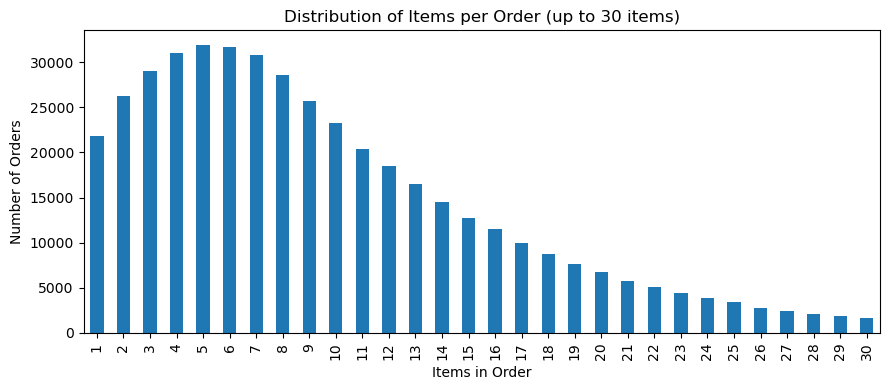

In [72]:

k_max = 30
dist.loc[:k_max].plot(kind='bar', figsize=(9, 4), title='Distribution of Items per Order (up to 30 items)')
plt.xlabel('Items in Order')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()



In [73]:
counts_reordered = (order_products.loc[order_products['reordered'] == 1, 'product_id']
                    .value_counts()
                    .head(20)
                    .rename_axis('product_id')
                    .reset_index(name='times_reordered'))
print(counts_reordered)


    product_id  times_reordered
0        24852            55763
1        13176            44450
2        21137            28639
3        21903            26233
4        47209            23629
5        47766            18743
6        27845            16251
7        47626            15044
8        27966            14748
9        16797            13945
10       26209            13327
11       22935            11145
12       24964            10411
13       45007            10076
14       49683             9538
15       28204             8989
16        8277             8836
17       39275             8799
18        5876             8412
19       49235             8389


In [74]:
top20_reordered = counts_reordered.merge(products[['product_id','product_name']],
                                         on='product_id', how='left')
print(top20_reordered)


    product_id  times_reordered              product_name
0        24852            55763                    Banana
1        13176            44450    Bag of Organic Bananas
2        21137            28639      Organic Strawberries
3        21903            26233      Organic Baby Spinach
4        47209            23629      Organic Hass Avocado
5        47766            18743           Organic Avocado
6        27845            16251        Organic Whole Milk
7        47626            15044               Large Lemon
8        27966            14748       Organic Raspberries
9        16797            13945              Strawberries
10       26209            13327                     Limes
11       22935            11145      Organic Yellow Onion
12       24964            10411            Organic Garlic
13       45007            10076          Organic Zucchini
14       49683             9538            Cucumber Kirby
15       28204             8989        Organic Fuji Apple
16        8277

In [75]:
print(top20_reordered[['product_id','product_name','times_reordered']])

    product_id              product_name  times_reordered
0        24852                    Banana            55763
1        13176    Bag of Organic Bananas            44450
2        21137      Organic Strawberries            28639
3        21903      Organic Baby Spinach            26233
4        47209      Organic Hass Avocado            23629
5        47766           Organic Avocado            18743
6        27845        Organic Whole Milk            16251
7        47626               Large Lemon            15044
8        27966       Organic Raspberries            14748
9        16797              Strawberries            13945
10       26209                     Limes            13327
11       22935      Organic Yellow Onion            11145
12       24964            Organic Garlic            10411
13       45007          Organic Zucchini            10076
14       49683            Cucumber Kirby             9538
15       28204        Organic Fuji Apple             8989
16        8277